# Qwen Text Seg inference (single image)

This notebook runs the **full** text-seg checkpoint with a single input image.

Steps:
1) Download weights into the repo root.
2) Set `INPUT_IMAGE_PATH` below.
3) Run all cells.

Notes:
- Uses `edit_image` only (same convention as `validate_lora/Qwen-Image-Edit-2511-LayeredVAE_FG_seg.py`).
- Outputs are saved to `output/qwen_text_seg_infer/`.

In [2]:
import os
from pathlib import Path

import torch
from PIL import Image
from IPython.display import display

from diffsynth.pipelines.qwen_image import QwenImagePipeline, ModelConfig
from diffsynth import load_state_dict


def _find_repo_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / "diffsynth").exists() and (parent / "pyproject.toml").exists():
            return parent
    return start


def _resolve_model_base(repo_root: Path) -> Path:
    env = os.environ.get("DIFFSYNTH_MODEL_BASE_PATH","/mnt/lica-data-2/for_jjseol/diffsynth_models")#"/mnt/local/diffsynth_models")
    if env:
        return Path(env)
    candidates = [
        repo_root / "diffsynth_models",
        Path("/mnt/lica-data-2/for_jjseol/diffsynth_models"),
        Path("/mnt/data/for_jjseol/diffsynth_models"),
    ]
    for cand in candidates:
        if (cand / "Qwen").exists():
            return cand
    return candidates[0]


REPO_ROOT = _find_repo_root(Path(".").resolve())
DEFAULT_MODEL_BASE = _resolve_model_base(REPO_ROOT)
print(f"[model] base: {DEFAULT_MODEL_BASE}")

PROMPT = "Extract the text layer."
SEED = 123
STEPS = 40

FULL_CKPT_DIR = Path("/mnt/lica-data-2/for_jjseol/diffsynth_models/train/Qwen-Image-Edit-2511_full_layered_vae_text_fg_seg")
FULL_CKPT = FULL_CKPT_DIR / "step-5000k.safetensors"

OUTPUT_DIR = REPO_ROOT / "output/qwen_text_seg_infer"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

[model] base: /mnt/lica-data-2/for_jjseol/diffsynth_models


In [3]:
import glob


def _model_config_local_only(local_glob: str, label: str) -> ModelConfig:
    paths = sorted(glob.glob(local_glob))
    if not paths:
        raise FileNotFoundError(f"[model] Missing local weights for {label}: {local_glob}")
    path_value = paths if len(paths) > 1 else paths[0]
    print(f"[model] Using local weights: {path_value}")
    return ModelConfig(path=path_value)


def _aux_config_local_only(local_dir: Path, label: str) -> ModelConfig:
    if not local_dir.exists():
        raise FileNotFoundError(f"[aux] Missing local assets for {label}: {local_dir}")
    print(f"[aux] Using local assets: {local_dir}")
    return ModelConfig(path=str(local_dir))


def _resolve_ckpt_path(path: Path) -> Path:
    if path.is_dir():
        candidates = sorted(path.glob("*.safetensors"), key=lambda p: p.stat().st_mtime)
        if not candidates:
            raise FileNotFoundError(f"No checkpoints found in: {path}")
        return candidates[-1]
    return path


device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.bfloat16 if device == "cuda" else torch.float32

model_base = DEFAULT_MODEL_BASE
qwen_root = model_base / "Qwen"

pipe = QwenImagePipeline.from_pretrained(
    torch_dtype=torch_dtype,
    device=device,
    model_configs=[
        _model_config_local_only(
            str(qwen_root / "Qwen-Image-Edit-2511" / "transformer" / "diffusion_pytorch_model-*.safetensors"),
            "Qwen-Image-Edit-2511 transformer",
        ),
        _model_config_local_only(
            str(qwen_root / "Qwen-Image" / "text_encoder" / "model*.safetensors"),
            "Qwen-Image text encoder",
        ),
        _model_config_local_only(
            str(qwen_root / "Qwen-Image-Layered" / "vae" / "diffusion_pytorch_model.safetensors"),
            "Qwen-Image-Layered VAE",
        ),
    ],
    tokenizer_config=None,
    processor_config=_aux_config_local_only(qwen_root / "Qwen-Image-Edit" / "processor", "Qwen-Image-Edit processor"),
)

ckpt_path = _resolve_ckpt_path(FULL_CKPT if FULL_CKPT.exists() else FULL_CKPT_DIR)
print(f"[ckpt] Using full checkpoint: {ckpt_path}")
state_dict = load_state_dict(str(ckpt_path))
pipe.dit.load_state_dict(state_dict)

[model] Using local weights: ['/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00001-of-00005.safetensors', '/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00002-of-00005.safetensors', '/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00003-of-00005.safetensors', '/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00004-of-00005.safetensors', '/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00005-of-00005.safetensors']
[model] Using local weights: ['/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00001-of-00004.safetensors', '/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00002-of-00004.safetensors', '/mnt/lica-data-2/for_jjseol/diffsy

AcceleratorError: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
def _checkerboard_rgba(size, tile=32):
    w, h = size
    light = (200, 200, 200, 255)
    dark = (160, 160, 160, 255)
    bg = Image.new("RGBA", size, light)
    tile_img = Image.new("RGBA", (tile, tile), dark)
    for y in range(0, h, tile):
        for x in range(0, w, tile):
            if (x // tile + y // tile) % 2 == 1:
                bg.paste(tile_img, (x, y))
    return bg

MAX_SIDE = 1024
ROUND_TO = 32
# When True, pipeline auto-resizes edit_image to ~1024x1024 area.
EDIT_IMAGE_AUTO_RESIZE = False
SHOW_INPUT_COPY = True


def _resize_edit_image(image, max_side=1024, round_to=32):
    w, h = image.size
    scale = min(1.0, max_side / max(w, h))
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))
    if round_to:
        new_w = max(round_to, (new_w // round_to) * round_to)
        new_h = max(round_to, (new_h // round_to) * round_to)
    if (new_w, new_h) != (w, h):
        image = image.resize((new_w, new_h), Image.LANCZOS)
    return image

INPUT_IMAGE_PATH = Path("/home/ubuntu/854f04d5-082a-450a-93aa-cf0d4ea362c0_generated_image.png")
if not INPUT_IMAGE_PATH.exists():
    raise FileNotFoundError(f"Input image not found: {INPUT_IMAGE_PATH}")

edit_image = Image.open(INPUT_IMAGE_PATH).convert("RGBA")
orig_size = edit_image.size
edit_image = _resize_edit_image(edit_image, max_side=MAX_SIDE, round_to=ROUND_TO)
if edit_image.size != orig_size:
    print(f"[input] resized {orig_size[0]}x{orig_size[1]} -> {edit_image.size[0]}x{edit_image.size[1]}")
width, height = edit_image.size
SEED += 1
STEPS = 10
PROMPT = "Extract the text layer."
result = pipe(
    PROMPT,
    edit_image=edit_image,
    seed=SEED,
    num_inference_steps=STEPS,
    height=height,
    width=width,
    edit_image_auto_resize=EDIT_IMAGE_AUTO_RESIZE,
    zero_cond_t=True,
)

# Match output size for display
output_rgba = result.convert("RGBA")
output_size = output_rgba.size
if edit_image.size != output_size:
    edit_image = edit_image.resize(output_size, Image.LANCZOS)

# Build preview: edit | output | (optional input copy)
checker_bg = _checkerboard_rgba(output_size)
output_composite = Image.alpha_composite(checker_bg, output_rgba)

out_w, out_h = output_size
canvas = Image.new("RGBA", (out_w * 2, out_h), (0, 0, 0, 0))
canvas.paste(edit_image, (0, 0))
canvas.paste(output_composite, (out_w, 0))
suffix = "pair"

out_path = OUTPUT_DIR / f"{INPUT_IMAGE_PATH.stem}_{suffix}.png"
canvas.save(out_path)

print(f"[done] saved to {out_path}")
display(canvas)

# Alpha mask where output alpha > 50
alpha = output_rgba.getchannel("A")
mask = alpha.point(lambda v: 255 if v > 20 else 0)
mask_path = OUTPUT_DIR / f"{INPUT_IMAGE_PATH.stem}_mask.png"
mask.save(mask_path)
print(f"[done] saved mask to {mask_path}")
display(mask)

NameError: name 'Path' is not defined

[done] saved mask to /home/ubuntu/DiffSynth-Studio/output/qwen_text_seg_infer/854f04d5-082a-450a-93aa-cf0d4ea362c0_generated_image_mask.png


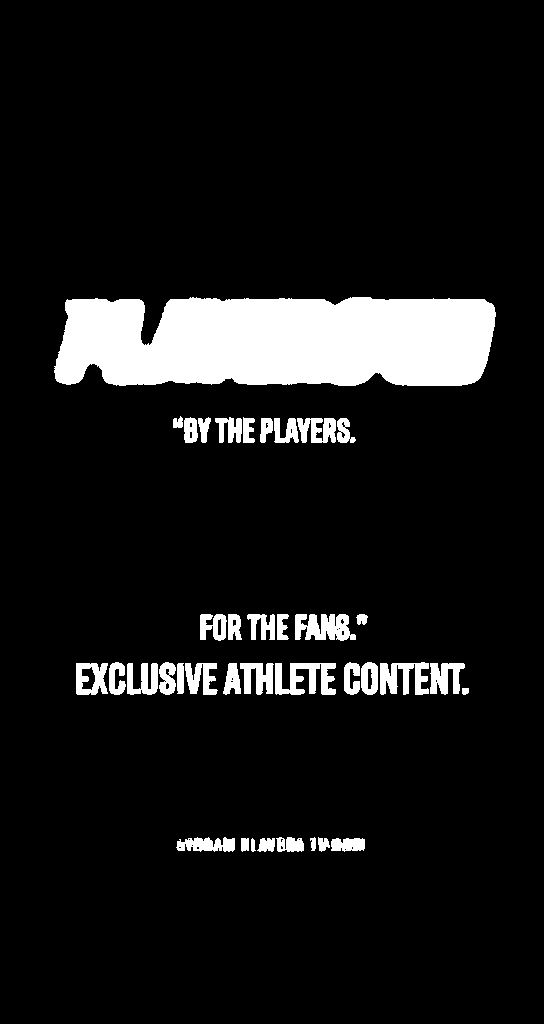

In [ ]:
alpha = output_rgba.getchannel("A")
mask = alpha.point(lambda v: 255 if v > 10 else 0)
mask_path = OUTPUT_DIR / f"{INPUT_IMAGE_PATH.stem}_mask.png"
mask.save(mask_path)
print(f"[done] saved mask to {mask_path}")
display(mask)